In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam,SGD
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
data=pd.read_csv('CAR DETAILS.csv')
data

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [3]:
data.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [4]:
data=data.drop('name',axis=1)
data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
data['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [7]:
data['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [8]:
data['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [9]:
le=LabelEncoder()
data['fuel']=le.fit_transform(data['fuel'])
data['seller_type']=le.fit_transform(data['seller_type'])
data['transmission']=le.fit_transform(data['transmission'])
data['owner']=le.fit_transform(data['owner'])
data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2007,60000,70000,4,1,1,0
1,2007,135000,50000,4,1,1,0
2,2012,600000,100000,1,1,1,0
3,2017,250000,46000,4,1,1,0
4,2014,450000,141000,1,1,1,2


In [10]:
x=data.drop('selling_price',axis=1)
y=data['selling_price']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=30)

In [12]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [13]:
model = Sequential()

model.add(Dense(5, input_dim=6, activation='relu',kernel_initializer='uniform'))
model.add(Dense(10, activation='relu',kernel_initializer='uniform'))
model.add(Dense(200, activation='relu',kernel_initializer='uniform'))
model.add(Dense(100, activation='relu',kernel_initializer='uniform'))
model.add(Dense(250, activation='relu',kernel_initializer='uniform'))
model.add(Dense(100, activation='relu',kernel_initializer='uniform'))
model.add(Dense(1, activation='relu',))  # output layer
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
)


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 5)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 200)                 │           2,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 250)                 │          25,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          25,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,846 (284.55 KB)

 Trainable params: 72,846 (284.55 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
training_history=model.fit(x_train,y_train,epochs=100,batch_size=100,validation_data=(x_test,y_test))

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 561547313152.0000 - val_loss: 670492393472.0000
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 561463296000.0000 - val_loss: 670109073408.0000
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 558748205056.0000 - val_loss: 660836974592.0000
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 523749294080.0000 - val_loss: 561268588544.0000
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 310510354432.0000 - val_loss: 240107995136.0000
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 168070873088.0000 - val_loss: 225426489344.0000
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 161557102592.0000 - val_loss: 222262181888.0000
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 160114950144.0000 - val_loss: 217894846464.0000
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 157315481600.0000 - val_loss: 215078912000.0000
Epoch 10/100
33/33 ━━━━━━━━━

In [16]:
hist=training_history.history
hist.keys()

dict_keys(['loss', 'val_loss'])

Text(0, 0.5, 'loss')

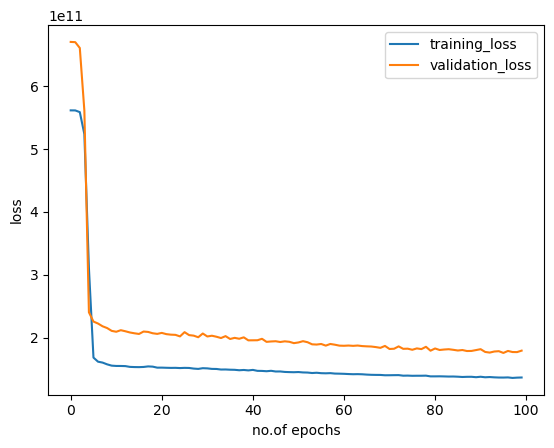

In [17]:
plt.plot(hist['loss'],label='training_loss')
plt.plot(hist['val_loss'],label='validation_loss')
plt.legend()
plt.xlabel('no.of epochs')
plt.ylabel('loss')